# PULPO Optimization Framework: Complete Demonstration

This notebook provides a comprehensive demonstration of PULPO's capabilities for sustainable technology optimization, covering basic single-objective optimization through advanced uncertainty analysis and multi-objective trade-off exploration.

## 1. System Description

The demonstration system models interconnected background and foreground processes for low-carbon methanol production:

**Background System** supplies conventional commodities:
- Natural gas extraction and electricity generation
- Wind electricity generation  
- Water supply
- Hydrogen production via steam methane reforming (SMR)
- Oxygen production via air separation unit (ASU)

**Foreground System** represents novel technologies:
- Hydrogen electrolysis (producing H₂ and O₂ as byproduct)
- Direct air capture (DAC) for CO₂ supply
- Methanol synthesis using captured CO₂ and H₂
- Ozone production consuming oxygen

**Multifunctional Links**: The O₂-byproduct and O₂-market activities balance oxygen flows between electrolysis byproduct recovery and conventional supply, ensuring proper system allocation.

**Environmental Flows**: The system tracks emissions of CO₂, CH₄, particulate matter (PM), and water use to the biosphere.

This represents an integrated Power-to-Methanol pathway with linked energy and material exchanges between renewable and fossil-based subsystems.

![Flowchart of the system](data/pulpo_showcase.png)

### 1.1 Technology Choices and System Interdependencies

The system incorporates several critical technological choices that determine environmental performance:

**Energy Supply Alternatives:**
- Electricity generation: Natural gas combined-cycle (NGCC) vs. wind power
- Represents background system choices reflecting alternative energy mixes

**Hydrogen Production Pathways:**
- Steam methane reforming (SMR) in background system
- Water electrolysis in foreground system  
- Demonstrates foreground-background substitution dynamics

**Oxygen Supply Options:**
- Conventional production via air separation unit (ASU) in background
- Recovery as electrolysis byproduct in foreground
- Market-based supply balancing both sources

The O₂-market activity ensures that multiple oxygen sources can coexist or compete depending on system boundaries and optimization objectives.

### 1.2 Technosphere Matrix (A)

The technosphere matrix represents product flows between processes. Positive values indicate outputs, negative values indicate inputs.

<table>
<thead>
<tr>
<th style="color:black;background-color:white;">Product ↓ \\ Process →</th>
<th style="background-color:#D9EAF7;color:black;">NG extraction</th>
<th style="background-color:#D9EAF7;color:black;">NG electricity</th>
<th style="background-color:#D9EAF7;color:black;">Wind electricity</th>
<th style="background-color:#D9EAF7;color:black;">Water supply</th>
<th style="background-color:#D9EAF7;color:black;">H₂ SMR</th>
<th style="background-color:#D9EAF7;color:black;">O₂ ASU</th>
<th style="background-color:#FFE5CC;color:black;">H₂ electrolysis</th>
<th style="background-color:#FFE5CC;color:black;">O₂-byproduct</th>
<th style="background-color:#FFE5CC;color:black;">O₂-market</th>
<th style="background-color:#FFE5CC;color:black;">DAC plant</th>
<th style="background-color:#FFE5CC;color:black;">Methanol synthesis</th>
<th style="background-color:#FFE5CC;color:black;">Ozone production</th>
</tr>
</thead>
<tbody>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Natural gas [kg]</b></td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:#D9EAF7;color:black;">−0.19</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">−3.2</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Electricity, NG [kWh]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">−0.49</td>
<td style="background-color:#D9EAF7;color:black;">−0.10</td>
<td style="background-color:#D9EAF7;color:black;">−0.22</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−1.2</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Electricity, wind [kWh]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−50.0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−1.5</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−0.5</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Water [m³]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:#D9EAF7;color:black;">−0.003</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−0.009</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Hydrogen (SMR) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Oxygen (ASU) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−1.0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Hydrogen (electrolysis) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−0.19</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Oxygen (byproduct) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+8.0</td>
<td style="background-color:#FFE5CC;color:black;">-1</td>
<td style="background-color:#FFE5CC;color:black;">−1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Oxygen (market) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>CO₂, captured [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td>
<td style="background-color:#FFE5CC;color:black;">−1.375</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Methanol [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Ozone [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td></tr>

</tbody>
</table>


### 1.3 Biosphere Matrix (B)

The biosphere matrix represents environmental flows from processes to the environment. All values represent emissions or resource consumption.

<table>
<thead>
<tr>
<th style="color:black;background-color:white;">Flow ↓  ---- \\ ---- Process →</th>
<th style="background-color:#D9EAF7;color:black;">NG extraction</th>
<th style="background-color:#D9EAF7;color:black;">NG electricity</th>
<th style="background-color:#D9EAF7;color:black;">Wind electricity</th>
<th style="background-color:#D9EAF7;color:black;">Water supply</th>
<th style="background-color:#D9EAF7;color:black;">H₂ SMR</th>
<th style="background-color:#D9EAF7;color:black;">O₂ ASU</th>
<th style="background-color:#FFE5CC;color:black;">H₂ electrolysis</th>
<th style="background-color:#FFE5CC;color:black;">O₂-byproduct</th>
<th style="background-color:#FFE5CC;color:black;">O₂-market</th>
<th style="background-color:#FFE5CC;color:black;">DAC plant</th>
<th style="background-color:#FFE5CC;color:black;">Methanol synthesis</th>
<th style="background-color:#FFE5CC;color:black;">Ozone production</th>
</tr>
</thead>
<tbody>

<tr><td style="color:black;background-color:white;"><b>CO₂ emission [kg]</b></td>
<td style="background-color:#D9EAF7;color:black;">+0.0</td>
<td style="background-color:#D9EAF7;color:black;">+0.44</td>
<td style="background-color:#D9EAF7;color:black;">+0.012</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+9.0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+0.1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−1.0</td>
<td style="background-color:#FFE5CC;color:black;">+0.2</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:white;"><b>CH₄ emission [kg]</b></td>
<td style="background-color:#D9EAF7;color:black;">+0.0074</td>
<td style="background-color:#D9EAF7;color:black;">+0.0000028</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:white;"><b>PM emission [g]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+0.015</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+0.001</td>
<td style="background-color:#FFE5CC;color:black;">+0.002</td></tr>

<tr><td style="color:black;background-color:white;"><b>Water use [m³]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+0.0018</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1.0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

</tbody>
</table>


## 2. Implementation: Basic Setup

### 2.1 Database Initialization

Initialize the sample database containing all processes and flows described in the system matrices. This creates both background and foreground databases with the complete methanol production system.

In [1]:
from pulpo import pulpo
pulpo.setup_sample_db()

07:48:37+0200

 [

info     

] 

07:48:38+0200

...

info     

] 

Vacuuming database            

foreground_db created with 6 activities and uncertainty added to exchanges.

Registered 3 LCIA methods.

### 2.2 Library Import

Import required libraries for optimization analysis and data manipulation.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import copy

### 2.3 PULPO Configuration

Configure the PULPO optimizer with:
- **Project name**: Identifier for optimization project
- **Databases**: Background (conventional) and foreground (novel) systems
- **Methods**: Impact assessment categories with relative weights
  - Climate change: weight = 1 (primary objective)
  - Resources: weight = 0 (inactive initially)

In [3]:
from pulpo.utils.utils import is_bw25

project = "sample_project_bw25" if is_bw25() else "sample_project"
database = ["background_db", "foreground_db"]
method = {"('my project', 'climate change')": 1,
          "('my project', 'resources')": 0,}

In [4]:
notebook_dir = os.path.dirname(os.getcwd())
directory = os.path.join(notebook_dir, 'data')

### 2.4 Optimizer Initialization

Create PULPO optimizer instance and configure data directory path.

In [5]:
pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)

> **⚠️ Attention:**  
> PULPO assumes that the biosphere in your project is named **`biosphere3`**.  
> If your project uses a different biosphere name, make sure to explicitly provide it to your PULPO worker.  
>  
> For example:

```python
pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
```


### 2.5 Life Cycle Inventory Data Loading

Load technosphere matrix (A), biosphere matrix (B), and process/intervention mappings. This creates the mathematical foundation for optimization by establishing the linear system: **Ax = f** and **environmental impacts = Bx**.

In [6]:
pulpo_worker.get_lci_data()

## 3. Single-Objective Optimization Examples

### 3.1 Functional Unit Definition

The functional unit defines the reference output for environmental impact assessment. We begin with 1 kg methanol as the primary product demand.

In [7]:
methanol_process = pulpo_worker.retrieve_processes(reference_products='methanol')

demand = {methanol_process[0]: 1}

### 3.2 Technology Choice Definition

Define alternative technologies for key system components:

**Electricity Generation:**
- Wind electricity (renewable)
- Natural gas electricity (fossil-based)

**Hydrogen Production:**
- Steam methane reforming (SMR) - conventional background process
- Water electrolysis - novel foreground process

**Oxygen Supply:**
- Air separation unit (ASU) - conventional production
- Market supply - generic oxygen source
- Electrolysis byproduct - recovered from hydrogen production

These alternatives represent the core technological decisions determining system environmental performance.

In [8]:
## Electricity Choice
electricity_technologies = ["wind electricity",
                            "natural gas electricity",]
electricity_processes = pulpo_worker.retrieve_processes(processes=electricity_technologies)

## Hydrogen Choice
hydrogen_technologies = ["hydrogen SMR",
                         "hydrogen electrolysis",]
hydrogen_processes = pulpo_worker.retrieve_processes(processes=hydrogen_technologies)

## Oxygen Choice
oxygen_technologies = ["O2-market",
                       "O2 ASU",]
oxygen_processes = pulpo_worker.retrieve_processes(processes=oxygen_technologies)

### Oxygen byproduct
oxygen_aux = "O2-byproduct"
oxygen_byproduct = pulpo_worker.retrieve_processes(processes=[oxygen_aux])


### 3.3 Choices Dictionary Configuration

Organize technology alternatives into an optimization-ready structure. Each choice category contains multiple alternatives with capacity constraints.

> **⚠️ Attention:**  
> A capacity of `float('inf')` means *no limit*: the solver is not restricted by it.  
> Give an alternative a finite capacity only where it has a real limit. A huge finite number such as `1e10` adds  
> nothing and can degrade the solver's numerics; leave it infinite instead.


In [9]:
## Choices
choices = {
    "Electricity": {electricity_processes[0]: float('inf'),
                    electricity_processes[1]: float('inf')},
    "Hydrogen": {hydrogen_processes[0]: float('inf'),
                 hydrogen_processes[1]: float('inf')},
    "Oxygen": {oxygen_processes[0]: float('inf'), 
               oxygen_processes[1]: float('inf'),},
}

### 3.4 Lower Bound Constraints

Configure process flow constraints. The O₂-byproduct process requires non-negative flow (≥ 0) to ensure physically meaningful byproduct recovery from electrolysis.

In [10]:
# Lower bound
lower_bound = {oxygen_byproduct[0]: 0}

> **⚠️ Attention:**  
> With this configuration, the O₂ by-product is **allowed to be vented** (e.g., to a market or directly to the environment).
> If you want to **force the system to internally utilize the by-product**, you must also specify an **upper bound of `0`**, which prevents any venting and requires full integration within the production system.


### 3.5 First Optimization: Single Product

Solve optimization with 1 kg methanol demand. PULPO identifies the technology combination minimizing climate change impact while satisfying demand constraints.

In [11]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound)
results = pulpo_worker.solve()

Creating Instance

Instance created

optimal solution found: 

1.7471600582975855

Optimization problem solved using Highspy

#### Results Analysis: Technology Selection

The optimization results show selected technologies and resource utilization. Observe which electricity and hydrogen sources were chosen to minimize climate impact.

In [12]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,1.74716


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,12.763338,inf


...

### Oxygen

,Value,Capacity
Metadata,,


## Constraints

### Constraints Lower

,Key,Metadata,Value,Limit
ID,,,,
7,"(foreground_db, O2-byproduct)",O2-byproduct | oxygen | GLO,1.52,0


### 3.6 Multi-Product Demand

Extend the system to include ozone production (2 kg) alongside methanol. This demonstrates PULPO's handling of multi-functional systems and oxygen flow optimization between different end uses.

In [13]:
ozone_process = pulpo_worker.retrieve_processes(reference_products='ozone')

demand = {methanol_process[0]: 1,
          ozone_process[0]: 2,}

#### Optimization: Multi-Product System

Solve with combined methanol and ozone demands. Oxygen byproduct from hydrogen electrolysis can now be utilized for ozone production, enabling potential system synergies.

In [14]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound)
results = pulpo_worker.solve()

Creating Instance

Instance created

optimal solution found: 

1.760427258456396

Optimization problem solved using Highspy

#### Results Analysis: Multi-Product System

Compare results with single-product case. Examine how oxygen flows changed and whether optimal technology choices shifted due to ozone demand integration.

In [15]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,1.760427


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,13.868938,inf


...

,Value,Capacity
Metadata,,
hydrogen electrolysis | hydrogen | GLO,0.19,inf


### Oxygen

,Value,Capacity
Metadata,,
O2-market | oxygen | GLO,1.52,inf
O2 ASU | oxygen | GLO,0.48,inf


## Constraints

'No constraint data to display.'

## 4. Constrained Optimization

### 4.1 Technology Capacity Constraints

Real-world technologies operate within finite capacity limits. Apply realistic constraints:
- Electricity sources: 8 units maximum each
- Hydrogen production: 0.1 units maximum each
- Oxygen supply: 1.2 units maximum each

These constraints force optimization within technological feasibility bounds.

In [16]:
## Choices
choices = {
    "Electricity": {electricity_processes[0]: 8, electricity_processes[1]: 8},
    "Hydrogen": {hydrogen_processes[0]: 0.1, hydrogen_processes[1]: 0.1},
    "Oxygen": {oxygen_processes[0]: 1.2, oxygen_processes[1]:1.2,},
}

#### Optimization: Capacity-Constrained System

Solve with active capacity constraints. This may require technology portfolio diversification rather than single-technology selection for environmental optimality.

In [17]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound)
results = pulpo_worker.solve()

Creating Instance

Instance created

optimal solution found: 

3.2944402907815795

Optimization problem solved using Highspy

#### Results Analysis: Impact of Capacity Constraints

Examine how technology mix and total environmental impact change under capacity limitations. The optimizer balances environmental optimality against technological feasibility.

In [18]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,3.29444


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,8.000000,8
natural gas electricity | electricity | GLO,1.536073,8


...

,Value,Capacity
Metadata,,
hydrogen electrolysis | hydrogen | GLO,0.10,0.1
hydrogen SMR | hydrogen | GLO,0.09,0.1


### Oxygen

,Value,Capacity
Metadata,,
O2 ASU | oxygen | GLO,1.2,1.2
O2-market | oxygen | GLO,0.8,1.2


## Constraints

'No constraint data to display.'

### 4.2 Resource Availability Constraints

Beyond technology capacity, resource availability represents another critical limitation. Constrain water supply to 1 m³ to simulate water scarcity scenarios.

In [19]:
water_process = pulpo_worker.retrieve_processes(reference_products='water')

In [20]:
upper_bound = {water_process[0]: 1}

#### Optimization: Combined Constraints

Apply both technology capacity limits and water availability constraints simultaneously. This represents realistic scenarios with multiple operational limitations.

In [21]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound, upper_limit=upper_bound)
results = pulpo_worker.solve()

Creating Instance

Instance created

optimal solution found: 

3.2944402907815795

Optimization problem solved using Highspy

#### Results Analysis: Resource Limitation Effects

Water limitation forces the system toward less water-intensive processes. Compare water consumption across scenarios to quantify constraint effects on technology selection.

In [22]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,3.29444


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,8.000000,8
natural gas electricity | electricity | GLO,1.536073,8


...

### Oxygen

,Value,Capacity
Metadata,,
O2 ASU | oxygen | GLO,1.2,1.2
O2-market | oxygen | GLO,0.8,1.2


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
3,"(background_db, water supply)",water supply | water | GLO,0.00117,1


### 4.3 Impact Category Switching

Demonstrate objective function flexibility by switching from climate change to resource use optimization. Different environmental priorities lead to distinct technology choices.

In [23]:
pulpo_worker.method = {"('my project', 'climate change')": 0,
          "('my project', 'resources')": 1,}

#### Optimization: Resource Efficiency Focus

Reset constraints to unconstrained levels and optimize for resource efficiency. This will likely select different technologies than climate-optimized solutions.

In [24]:
## Choices
choices = {
    "Electricity": {electricity_processes[0]: float('inf'), electricity_processes[1]: float('inf')},
    "Hydrogen": {hydrogen_processes[0]: float('inf'), hydrogen_processes[1]: float('inf')},
    "Oxygen": {oxygen_processes[0]: float('inf'), oxygen_processes[1]: float('inf'),},
}

In [25]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound)
results = pulpo_worker.solve()

Creating Instance

Instance created

optimal solution found: 

0.0005699999978020787

Optimization problem solved using Highspy

#### Results Analysis

Compare resource-optimized results with climate change optimization. Different environmental priorities (climate vs. resources) yield different optimal technology portfolios, demonstrating the importance of multi-criteria decision-making in sustainable technology design.

In [26]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'resources')",1,0.00057


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,4.721779,inf


...

,Value,Capacity
Metadata,,
hydrogen SMR | hydrogen | GLO,0.19,inf


### Oxygen

,Value,Capacity
Metadata,,
O2 ASU | oxygen | GLO,2.0,inf


## Constraints

'No constraint data to display.'

## 5. Summary: Core PULPO Capabilities

This demonstration covered PULPO's fundamental optimization features:

**System Integration:**
- Multi-database integration (background + foreground systems)
- Technology choice optimization across energy, hydrogen, and oxygen sources
- Multi-product system optimization with material flow synergies

**Constraint Handling:**
- Technology capacity constraints (realistic deployment limits)
- Resource availability constraints (scarcity scenarios)
- Process flow constraints (physical feasibility)

**Multi-Criteria Analysis:**
- Objective function flexibility (climate change vs. resource use)
- Technology trade-off analysis under different environmental priorities
- Impact assessment across multiple environmental categories

## 6. Multi-Objective Optimization: Pareto Front Analysis

Explore trade-offs between competing objectives through Pareto front generation. This analysis reveals how environmental performance varies when balancing climate change and resource use priorities using the epsilon-constraint method.

### 6.1 Multi-Objective Setup

Create dual-objective PULPO worker with equal weighting for both climate change and resource use objectives to establish baseline performance ranges.

In [27]:
# Create multi-objective method configuration
methods_multi = {
    "('my project', 'climate change')": 1,
    "('my project', 'resources')": 1
}

# Initialize multi-objective PULPO worker
pulpo_worker_multi = pulpo.PulpoOptimizer(project, database, methods_multi, directory)
pulpo_worker_multi.get_lci_data()

print("Multi-objective PULPO worker created with both climate change and resource use objectives")

Multi-objective PULPO worker created with both climate change and resource use objectives

### 6.2 Extreme Point Identification

Determine boundary solutions for Pareto front generation:
1. **Climate-optimal solution**: Minimize climate change (resource use unconstrained)
2. **Resource-optimal solution**: Minimize resource use (climate change unconstrained)

These extreme points define the feasible range for epsilon constraints.

In [28]:
# 1. Find climate-optimal solution (minimize climate change)
methods_climate = {
    "('my project', 'climate change')": 1,
    "('my project', 'resources')": 0
}

pulpo_worker_climate = pulpo.PulpoOptimizer(project, database, methods_climate, directory)
pulpo_worker_climate.get_lci_data()

# Use unconstrained choices for extreme points
choices_unconstrained = {
    "Electricity": {electricity_processes[0]: float('inf'), electricity_processes[1]: float('inf')},
    "Hydrogen": {hydrogen_processes[0]: float('inf'), hydrogen_processes[1]: float('inf')},
    "Oxygen": {oxygen_processes[0]: float('inf'), oxygen_processes[1]: float('inf')},
}

pulpo_worker_climate.instantiate(choices=choices_unconstrained, demand=demand, lower_limit=lower_bound)
results_climate = pulpo_worker_climate.solve()

# Extract optimal impacts
climate_optimal_cc = pulpo_worker_climate.instance.impacts_calculated["('my project', 'climate change')"].value
climate_optimal_res = pulpo_worker_climate.instance.impacts_calculated["('my project', 'resources')"].value

print(f"Climate-optimal solution:")
print(f"  Climate change: {climate_optimal_cc:.4f}")
print(f"  Resource use: {climate_optimal_res:.4f}")

Creating Instance

Instance created

optimal solution found: 

1.760427258456396

Optimization problem solved using Highspy

Climate-optimal solution:

  Climate change: 1.7604

  Resource use: 0.0017

In [29]:
# 2. Find resource-optimal solution (minimize resource use)
methods_resource = {
    "('my project', 'climate change')": 0,
    "('my project', 'resources')": 1
}

pulpo_worker_resource = pulpo.PulpoOptimizer(project, database, methods_resource, directory)
pulpo_worker_resource.get_lci_data()

pulpo_worker_resource.instantiate(choices=choices_unconstrained, demand=demand, lower_limit=lower_bound)
results_resource = pulpo_worker_resource.solve()

# Extract optimal impacts
resource_optimal_cc = pulpo_worker_resource.instance.impacts_calculated["('my project', 'climate change')"].value
resource_optimal_res = pulpo_worker_resource.instance.impacts_calculated["('my project', 'resources')"].value

print(f"Resource-optimal solution:")
print(f"  Climate change: {resource_optimal_cc:.4f}")
print(f"  Resource use: {resource_optimal_res:.4f}")

print(f"\nObjective ranges:")
print(f"  Climate change: {climate_optimal_cc:.4f} to {resource_optimal_cc:.4f}")
print(f"  Resource use: {resource_optimal_res:.4f} to {climate_optimal_res:.4f}")

Creating Instance

Instance created

optimal solution found: 

0.0005699999978020787

Optimization problem solved using Highspy

...

  Climate change: 3.4753

  Resource use: 0.0006


Objective ranges:

  Climate change: 1.7604 to 3.4753

  Resource use: 0.0006 to 0.0017

### 6.3 Epsilon-Constraint Implementation

Generate Pareto front using systematic constraint variation:
- **Primary objective**: Minimize resource use
- **Secondary objective**: Climate change (constrained via upper impact limits)
- **Method**: Vary climate change constraint from climate-optimal to resource-optimal values

In [30]:
# Generate epsilon constraints for climate change
n_points = 8  # Number of Pareto points
epsilon_list = np.linspace(climate_optimal_cc, resource_optimal_cc, num=n_points)

# Initialize empty list to store Pareto front data
pareto_front = []

# Category names for easier reference
cc_category = "('my project', 'climate change')"
res_category = "('my project', 'resources')"

print(f"Generating Pareto front with {n_points} points...")
print(f"Climate change constraint range: {climate_optimal_cc:.4f} to {resource_optimal_cc:.4f}")
print("=" * 60)

# Configure worker for epsilon-constraint (minimize resources, constrain climate)
methods_epsilon = {
    "('my project', 'climate change')": 0,
    "('my project', 'resources')": 1
}

pulpo_worker_pareto = pulpo.PulpoOptimizer(project, database, methods_epsilon, directory)
pulpo_worker_pareto.get_lci_data()

for i, epsilon in enumerate(epsilon_list):
    print(f"Point {i+1}/{n_points}: Climate constraint = {epsilon:.4f}")
    
    # Set up epsilon constraint
    epsilon_constraint = {cc_category: epsilon}
    
    # Solve with climate change constraint
    pulpo_worker_pareto.instantiate(
        choices=choices_unconstrained, 
        demand=demand, 
        lower_limit=lower_bound,
        upper_imp_limit=epsilon_constraint
    )
    results = pulpo_worker_pareto.solve()
    

    impacts = {x: pulpo_worker_pareto.instance.impacts_calculated[x].value for x in pulpo_worker_pareto.instance.impacts_calculated}
    
    # Store Pareto point (resource use, climate change)
    pareto_point = (impacts[res_category], impacts[cc_category])
    pareto_front.append(pareto_point)
    
    print(f"  → Resource use: {impacts[res_category]:.4f}")
    print(f"  → Climate change: {impacts[cc_category]:.4f}")
    print()

print(f"Pareto front generation complete: {len(pareto_front)} feasible points")

Generating Pareto front with 8 points...

Climate change constraint range: 1.7604 to 3.4753

Point 1/8: Climate constraint = 1.7604

Creating Instance

Instance created

...

0.0005699999978020787

Optimization problem solved using Highspy

  → Resource use: 0.0006

  → Climate change: 3.4753

Pareto front generation complete: 8 feasible points

### 6.4 Pareto Front Visualization

Generate comprehensive visualization showing trade-offs between climate change and resource use across the complete feasible solution space.

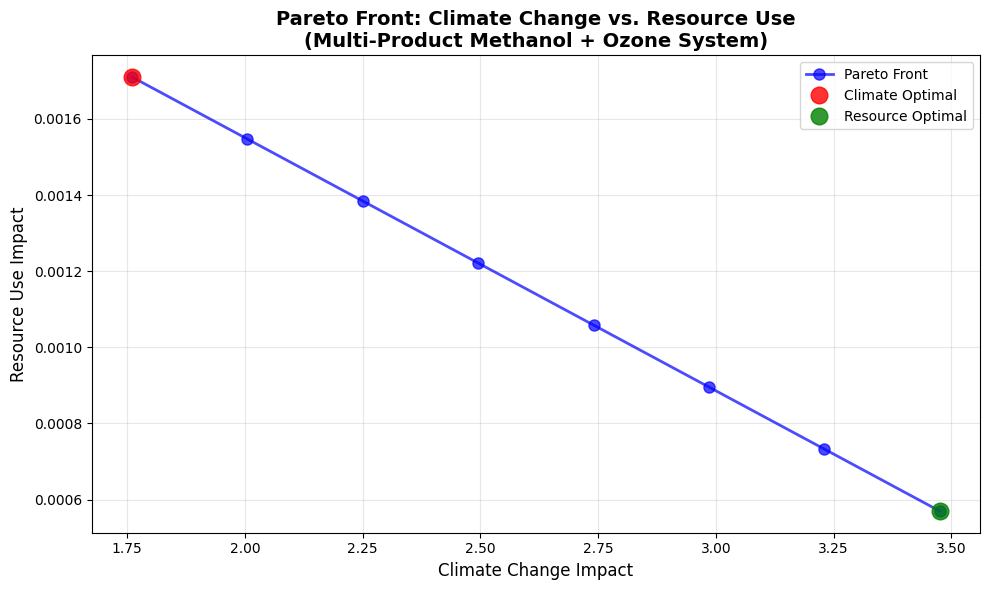

📈 PARETO FRONT ANALYSIS

Number of Pareto points: 8


Climate Change Range:

  Best: 1.7604

  Worst: 3.4753

  Range: 1.7149


Resource Use Range:

  Best: 0.0006

  Worst: 0.0017

  Range: 0.0011

In [31]:
import matplotlib.pyplot as plt

# Extract data for plotting
if pareto_front:
    resource_values = [point[0] for point in pareto_front]
    climate_values = [point[1] for point in pareto_front]
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot Pareto front
    plt.plot(climate_values, resource_values, 'bo-', linewidth=2, markersize=8, 
             label='Pareto Front', alpha=0.7)
    
    # Highlight extreme points
    plt.plot(climate_optimal_cc, climate_optimal_res, 'ro', markersize=12, 
             label='Climate Optimal', alpha=0.8)
    plt.plot(resource_optimal_cc, resource_optimal_res, 'go', markersize=12, 
             label='Resource Optimal', alpha=0.8)
    
    # Formatting
    plt.xlabel('Climate Change Impact', fontsize=12)
    plt.ylabel('Resource Use Impact', fontsize=12)
    plt.title('Pareto Front: Climate Change vs. Resource Use\n(Multi-Product Methanol + Ozone System)', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("📈 PARETO FRONT ANALYSIS")
    print("=" * 40)
    print(f"Number of Pareto points: {len(pareto_front)}")
    print(f"\nClimate Change Range:")
    print(f"  Best: {min(climate_values):.4f}")
    print(f"  Worst: {max(climate_values):.4f}")
    print(f"  Range: {max(climate_values) - min(climate_values):.4f}")
    print(f"\nResource Use Range:")
    print(f"  Best: {min(resource_values):.4f}")
    print(f"  Worst: {max(resource_values):.4f}")
    print(f"  Range: {max(resource_values) - min(resource_values):.4f}")
    
else:
    print("No feasible Pareto points found")

## 7. Uncertainty Analysis: Monte Carlo Simulation

Real-world systems contain parameter uncertainties that propagate through optimization results. PULPO's Monte Carlo capabilities enable robustness assessment and uncertainty quantification for environmental impact optimization.

**Analysis Objectives:**
- Quantify parameter uncertainty effects on optimal solutions
- Assess result robustness across uncertainty ranges
- Analyze correlation between environmental objectives under uncertainty
- Give 90% intervals for the optimal impacts

### 7.1 Uncertainty Worker Configuration

Configure specialized PULPO worker for uncertainty analysis with climate change minimization as primary objective while tracking both impact categories.

In [32]:
# Create uncertainty analysis worker focusing on climate change
methods_uncertainty = {
    "('my project', 'climate change')": 1,
    "('my project', 'resources')": 1e-20,
}

# Initialize uncertainty PULPO worker
pulpo_worker_unc = pulpo.PulpoOptimizer(project, database, methods_uncertainty, directory)
pulpo_worker_unc.get_lci_data()

print("Uncertainty analysis PULPO worker created successfully")
print("Objective: Minimize climate change impact under parameter uncertainty")

Uncertainty analysis PULPO worker created successfully

Objective: Minimize climate change impact under parameter uncertainty

### 7.2 Monte Carlo Parameter Configuration

Configure system parameters for uncertainty analysis:
- **Demand specification**: Multi-product system (1 kg methanol + 2 kg ozone)
- **Technology options**: All electricity, hydrogen, and oxygen alternatives available
- **Constraints**: Unconstrained capacities for computational clarity
- **Uncertainty source**: Parameter sampling from database uncertainty distributions

In [33]:
# Configure same system as before for uncertainty analysis
# Multi-product demand: methanol + ozone
demand_unc = {methanol_process[0]: 1, ozone_process[0]: 2}

# Technology choices (unconstrained for clarity)
choices_unc = {
    "Electricity": {electricity_processes[0]: float('inf'), electricity_processes[1]: float('inf')},
    "Hydrogen": {hydrogen_processes[0]: float('inf'), hydrogen_processes[1]: float('inf')},
    "Oxygen": {oxygen_processes[0]: float('inf'), oxygen_processes[1]: float('inf')},
}

# Lower bounds
lower_bound_unc = {oxygen_byproduct[0]: 0}

print("System configuration for uncertainty analysis:")
print(f"  Demand: {len(demand_unc)} products")
print(f"  Technology choices: {len(choices_unc)} categories")
print(f"  Lower bounds: {len(lower_bound_unc)} constraints")

System configuration for uncertainty analysis:

  Demand: 2 products

  Technology choices: 3 categories

  Lower bounds: 1 constraints

### 7.3 Monte Carlo Execution

Execute Monte Carlo simulation using `solve_MC` function:
1. **Problem instantiation** with specified configuration
2. **Parameter sampling** across multiple iterations from uncertainty distributions
3. **Optimization solving** for each parameter realization
4. **Result collection** across all Monte Carlo iterations

The function automatically handles parameter uncertainty sampling from database distributions.

In [34]:
# Run Monte Carlo simulation
print("🎲 Starting Monte Carlo simulation...")
print("=" * 50)

# Number of Monte Carlo iterations
n_iterations = 500

# Run Monte Carlo analysis
pulpo_worker_unc.instantiate(choices=choices_unc, demand=demand_unc, lower_limit=lower_bound_unc)
mc_results = pulpo_worker_unc.solve_MC(
    n_it=n_iterations
)

print(f"✅ Monte Carlo simulation completed successfully!")
print(f"   Total iterations: {n_iterations}")
print(f"   Results structure: dict with {len(mc_results)} entries")
print(f"   Available result keys per iteration: {list(next(iter(mc_results.values())).keys())}")


🎲 Starting Monte Carlo simulation...

Creating Instance

Instance created

Pre-sampling 500 LCI matrix sets...

Solving 500 Monte Carlo optimizations in parallel...

Running 500 Monte Carlo optimizations in parallel (n_jobs=-1)...

✅ Monte Carlo simulation completed successfully!

   Total iterations: 500

   Results structure: dict with 500 entries

   Available result keys per iteration: ['Scaling Vector', 'Intervention Vector', 'Slack', 'Impacts', 'Transgressions', 'Demand', 'Choices', 'Constraints Upper', 'Constraints Lower', 'Constraints Upper Elem']

### 7.4 Statistical Analysis

Collect the optimal impacts of every sample and summarize them: mean, standard deviation, 90% interval (5th to 95th percentile) and the correlation between the two impact categories.

In [35]:
mc_results[0]['Impacts']

,Weight,Value
Method,,
"('my project', 'climate change')",1.000000e+00,1.792682
"('my project', 'resources')",1.000000e-20,0.001620


In [36]:
# Extract both climate change and resource impacts from Monte Carlo results

climate_key = "('my project', 'climate change')"
resource_key = "('my project', 'resources')"

if isinstance(mc_results, dict) and len(mc_results) > 0:
    print(f"Extracting both climate change and resource impacts from {len(mc_results)} Monte Carlo iterations...")
    
    climate_impacts = []
    resource_impacts = []
    successful_iterations = 0
    
    for i, iteration_result in mc_results.items():
        try:
            if "error" in iteration_result:
                continue
            # Access impact values from the Impacts DataFrame
            impacts_df = iteration_result["Impacts"]
            climate_value = impacts_df.loc[climate_key, "Value"]
            resource_value = impacts_df.loc[resource_key, "Value"]
            
            if climate_value is not None and resource_value is not None:
                climate_impacts.append(climate_value)
                resource_impacts.append(resource_value)
                successful_iterations += 1
        except (KeyError, AttributeError) as e:
            print(f"Warning: Could not extract impacts from iteration {i}: {e}")
            continue
    
    print(f"Successfully extracted impacts from {successful_iterations}/{len(mc_results)} iterations")
    
    if len(climate_impacts) > 0 and len(resource_impacts) > 0:
        # Convert to numpy arrays for analysis
        climate_impacts = np.array(climate_impacts)
        resource_impacts = np.array(resource_impacts)
        
        # Calculate statistical measures for climate change
        climate_mean = np.mean(climate_impacts)
        
        # Calculate statistical measures for resource use
        resource_mean = np.mean(resource_impacts)

        climate_std, resource_std = np.std(climate_impacts, ddof=1), np.std(resource_impacts, ddof=1)
        climate_90 = np.percentile(climate_impacts, [5, 95])
        resource_90 = np.percentile(resource_impacts, [5, 95])
        correlation = np.corrcoef(climate_impacts, resource_impacts)[0, 1]
        print(f"Climate change: mean {climate_mean:.4f}, std {climate_std:.4f}, "
              f"90% interval [{climate_90[0]:.4f}, {climate_90[1]:.4f}]")
        print(f"Resource use:   mean {resource_mean:.4f}, std {resource_std:.4f}, "
              f"90% interval [{resource_90[0]:.4f}, {resource_90[1]:.4f}]")
        print(f"Correlation between the two impacts: {correlation:.2f}")

Extracting both climate change and resource impacts from 500 Monte Carlo iterations...

Successfully extracted impacts from 500/500 iterations

Climate change: mean 1.7572, std 0.2826, 90% interval [1.3101, 2.2638]

Resource use:   mean 0.0017, std 0.0004, 90% interval [0.0012, 0.0023]

Correlation between the two impacts: 0.06

### 7.5 Uncertainty Visualization

The joint density of the two optimal impacts over all samples, with their means.

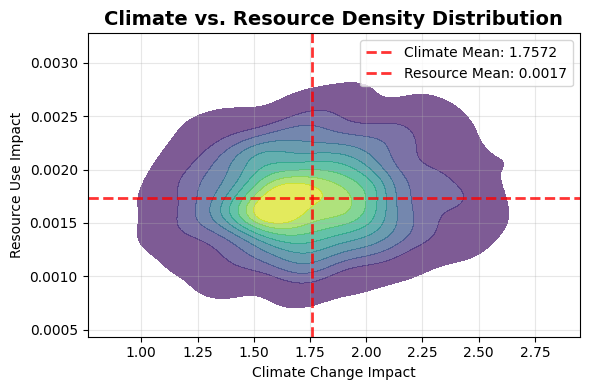

In [37]:
if climate_impacts is not None and resource_impacts is not None and len(climate_impacts) > 0:
    import seaborn as sns
    
    # Create elegant dual-objective uncertainty visualization
    fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
    
    # 1. Seaborn KDE plot for density distribution
    ax1.set_title('Climate vs. Resource Density Distribution', fontsize=14, fontweight='bold')
    sns.kdeplot(x=climate_impacts, y=resource_impacts, cmap='viridis', fill=True, 
                thresh=0.02, ax=ax1, alpha=0.7)
    
    # Add mean lines
    ax1.axvline(climate_mean, color='red', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Climate Mean: {climate_mean:.4f}')
    ax1.axhline(resource_mean, color='red', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Resource Mean: {resource_mean:.4f}')
    
    ax1.set_xlabel('Climate Change Impact')
    ax1.set_ylabel('Resource Use Impact')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("❌ Cannot create visualization - missing valid impact data for both objectives")

> **See also:** `pulpo.utils.uncertainty` for the uncertainty of an impact from its declared distributions: closed-form moments and chance-constrained optimization in reduced space ([uncertainty toy notebook](uncertainty_toy.ipynb)).

## 8. Infeasible Problems

Limits that cannot all be met make the optimization problem infeasible. PULPO then raises a `SolveError` (from `pulpo.utils.optimizer`) and loads nothing: the worker keeps its previous solution. The same happens when a solve stops early, for example at a time limit.

Limits belong on the processes, flows and impacts that really have one (`lower_limit`, `upper_limit`, `upper_elem_limit`, `upper_imp_limit`, ...), as in section 4. Bounds on every activity through `default_limits` have no physical meaning; they raise a `FutureWarning`, and `default_limits` may be deprecated in a near-future release.

### 8.1 The Lowest Achievable Impact

Solve the unconstrained problem to find the lowest climate change impact the system can reach.

In [38]:
from pulpo.utils.optimizer import SolveError

climate = "('my project', 'climate change')"
methods_default = {climate: 1, "('my project', 'resources')": 0}
pulpo_worker_default = pulpo.PulpoOptimizer(project, database, methods_default, directory)
pulpo_worker_default.get_lci_data()

pulpo_worker_default.instantiate(choices=choices_unconstrained, demand=demand, lower_limit=lower_bound)
pulpo_worker_default.solve()
lowest_climate = pulpo_worker_default.instance.impacts_calculated[climate].value
print(f"Lowest achievable climate change impact: {lowest_climate:.6f}")

Creating Instance

Instance created

optimal solution found: 

1.760427258456396

Optimization problem solved using Highspy

Lowest achievable climate change impact: 1.760427

### 8.2 A Limit Below It

Ask for half of that impact. No combination of technologies reaches it, so the solve raises a `SolveError`:

In [39]:
pulpo_worker_default.instantiate(choices=choices_unconstrained, demand=demand, lower_limit=lower_bound,
                                 upper_imp_limit={climate: lowest_climate / 2})
try:
    pulpo_worker_default.solve()
except SolveError as error:
    print(f"No solution: {error}")

Creating Instance

Instance created

No solution: HiGHS did not solve the model to optimality (infeasible); the instance keeps its previous values. The solver's results are on the exception's .results.

## 9. Dependent Constraints: Technology Coupling

Real-world systems often require interdependent technology operation rules. PULPO's dependent constraints enable specification of relationships between different process scaling levels, allowing for operational constraints, market share limitations, or technology coupling requirements.

**Use Cases:**
- Maximum renewable energy penetration limits
- Technology deployment ratios
- Supply chain coordination constraints
- Market share limitations
- Infrastructure coupling requirements

### 9.1 Market Penetration Constraint

Implement a realistic constraint where wind electricity can constitute a maximum of 80% of total electricity production. This represents grid stability or market penetration limitations for renewable energy sources.

**Constraint Formulation:**
- Wind electricity ≤ 0.8 × (Wind electricity + Gas electricity)
- Mathematical rearrangement: Wind ≤ 4 × Gas electricity
- Ensures renewable energy integration within practical bounds

In [40]:
# Configure PULPO worker for dependent constraints demonstration
methods_dependent = {"('my project', 'climate change')": 1, "('my project', 'resources')": 0}
pulpo_worker_dep = pulpo.PulpoOptimizer(project, database, methods_dependent, directory)
pulpo_worker_dep.get_lci_data()

# Retrieve electricity technologies specifically by name for clarity
wind_electricity = pulpo_worker_dep.retrieve_processes(processes=['wind electricity'])
gas_electricity = pulpo_worker_dep.retrieve_processes(processes=['natural gas electricity'])

print("Retrieved electricity technologies:")
print(f"  Wind electricity: {wind_electricity[0]['name']}")
print(f"  Gas electricity: {gas_electricity[0]['name']}")

# Multi-product demand (1 kg methanol + 2 kg ozone)
demand_dep = {methanol_process[0]: 1, ozone_process[0]: 2}
print(f"\nDemand specification: {len(demand_dep)} products")

Retrieved electricity technologies:

  Wind electricity: wind electricity

  Gas electricity: natural gas electricity


Demand specification: 2 products

In [41]:
# Define dependent constraint: Wind ≤ 80% of total electricity
# Mathematical form: wind ≤ 4 × gas_electricity (derived from wind ≤ 0.8 × (wind + gas))
dependent_constraints = {
    'wind_penetration_limit': {
        'left': {wind_electricity[0]: 1},        # Wind electricity scaling
        'right': {gas_electricity[0]: 4}         # 4 × Gas electricity scaling
    }
}

# Technology choices (allow both options)
choices_dep = {
    "Electricity": {wind_electricity[0]: float('inf'), gas_electricity[0]: float('inf')},
    "Hydrogen": {hydrogen_processes[0]: float('inf'), hydrogen_processes[1]: float('inf')},
    "Oxygen": {oxygen_processes[0]: float('inf'), oxygen_processes[1]: float('inf')},
}

# Lower bounds for physical feasibility
lower_bound_dep = {oxygen_byproduct[0]: 0}

print("Dependent constraint configuration:")
print("  Constraint: Wind electricity ≤ 4 × Gas electricity")
print("  Interpretation: Wind ≤ 80% of total electricity production")
print(f"  Technology choices: {len(choices_dep)} categories available")

Dependent constraint configuration:

  Constraint: Wind electricity ≤ 4 × Gas electricity

  Interpretation: Wind ≤ 80% of total electricity production

  Technology choices: 3 categories available

In [42]:
# Solve optimization with dependent constraints
print("🔄 Solving optimization with wind penetration constraint...")

pulpo_worker_dep.instantiate(
    choices=choices_dep, 
    demand=demand_dep, 
    lower_limit=lower_bound_dep,
    dependent_constraints=dependent_constraints
)

results_dep = pulpo_worker_dep.solve()

# Extract scaling values for analysis
scaling_results = {}
for activity_name, process_id in pulpo_worker_dep.lci_data['process_map'].items():
    if pulpo_worker_dep.instance.scaling_vector[process_id].value > 1e-6:  # Only show active processes
        scaling_results[activity_name[1]] = pulpo_worker_dep.instance.scaling_vector[process_id].value

print("✅ Optimization completed successfully!")
print("\nActive process scaling values:")
for process_name, scaling_value in scaling_results.items():
    print(f"  {process_name}: {scaling_value:.4f}")

🔄 Solving optimization with wind penetration constraint...

Creating Instance

Instance created

optimal solution found: 

3.0636673756672597

...

  hydrogen electrolysis: 0.1900

  O2-market: 1.5200

  direct air capture: 1.3750

  methanol synthesis: 1.0000

  ozone production: 2.0000

In [43]:
# Verify constraint satisfaction and analyze electricity mix
wind_scaling = scaling_results.get('wind electricity', 0)
gas_scaling = scaling_results.get('natural gas electricity', 0)
total_electricity = wind_scaling + gas_scaling

if total_electricity > 0:
    wind_percentage = (wind_scaling / total_electricity) * 100
    constraint_satisfied = wind_scaling <= (4 * gas_scaling + 1e-6)
    climate_impact = pulpo_worker_dep.instance.impacts_calculated["('my project', 'climate change')"].value
    
    print(f"\n📊 CONSTRAINT VERIFICATION")
    print(f"Wind: {wind_scaling:.4f} | Gas: {gas_scaling:.4f} | Wind %: {wind_percentage:.1f}%")
    print(f"Constraint satisfied: {constraint_satisfied} (wind ≤ 4×gas: {wind_scaling:.4f} ≤ {4*gas_scaling:.4f})")
    print(f"Climate impact: {climate_impact:.4f}")
else:
    print("⚠️ No electricity production detected")


📊 CONSTRAINT VERIFICATION

Wind: 11.0952 | Gas: 2.7738 | Wind %: 80.0%

Constraint satisfied: True (wind ≤ 4×gas: 11.0952 ≤ 11.0952)

Climate impact: 3.0637

## 10. Supply Specification: Fixing a Process Output

All previous examples are *demand-driven*: a functional unit is specified and the system must deliver it. PULPO also supports *supply-driven* analysis. When a process is given **identical lower and upper limits**, its scaling is fixed to exactly that value, and PULPO automatically activates a **slack variable** for the corresponding reference product. The slack relaxes the product balance, so the fixed output does not need to be absorbed by a final demand — the question becomes:

> *“What is the optimal system configuration (and what are its impacts) when this process runs at exactly this level?”*

**Use Cases:**
- Assessing an existing plant operating at a known production level
- Impact accounting for a fixed production quota rather than a functional unit
- Analyzing systems where the output is determined by upstream availability (e.g., waste treatment capacity) instead of downstream demand

### 10.1 Supply-Driven Optimization: Fixed Methanol Output

Fix the methanol synthesis process to a scaling of exactly 1 by passing the **same value as lower and upper limit**. No demand is specified — the fixed supply alone drives the system. The technology choices remain open, so the optimizer still selects the impact-minimal electricity, hydrogen, and oxygen sources needed to run the fixed process.

In [44]:
# Configure a fresh worker for the supply-driven demonstration
methods_supply = {"('my project', 'climate change')": 1, "('my project', 'resources')": 0}
pulpo_worker_supply = pulpo.PulpoOptimizer(project, database, methods_supply, directory)
pulpo_worker_supply.get_lci_data()

# Identical lower and upper limit -> scaling is fixed and the supply slack is activated
methanol_supply = {methanol_process[0]: 1}

# Technology choices remain open for the optimizer
choices_supply = {
    "Electricity": {electricity_processes[0]: float('inf'), electricity_processes[1]: float('inf')},
    "Hydrogen": {hydrogen_processes[0]: float('inf'), hydrogen_processes[1]: float('inf')},
    "Oxygen": {oxygen_processes[0]: float('inf'), oxygen_processes[1]: float('inf')},
}

# Note: no demand is passed!
pulpo_worker_supply.instantiate(
    choices=choices_supply,
    lower_limit={**methanol_supply, oxygen_byproduct[0]: 0},
    upper_limit=methanol_supply,
)
results_supply = pulpo_worker_supply.solve()

supply_climate = pulpo_worker_supply.instance.impacts_calculated["('my project', 'climate change')"].value
print(f"Supply-driven climate impact: {supply_climate:.6f}")

Creating Instance

Instance created

optimal solution found: 

1.7471600582975855

Optimization problem solved using Highspy

Supply-driven climate impact: 1.747160

#### Results Analysis: Slack Activation

The slack variable exists **only** for the methanol product (the model carries no slack for any other product). Its value equals the fixed methanol output that is not consumed by any demand — the balance `production = demand + slack` closes with `demand = 0`, so the slack absorbs the full supply of 1.

In [45]:
# The slack absorbs the fixed methanol output that no demand consumes
slack = pulpo_worker_supply.extract_results()['Slack']
print("Slack (exists only for the supply product):")
print(slack)

methanol_id = pulpo_worker_supply.lci_data['process_map'][methanol_process[0].key]
print(f"Methanol synthesis scaling (fixed): {pulpo_worker_supply.instance.scaling_vector[methanol_id].value:.4f}")

Slack (exists only for the supply product):

    Value
10    1.0

Methanol synthesis scaling (fixed): 1.0000

### 10.2 Comparison with the Demand-Driven Formulation

For this system the supply-driven and demand-driven formulations coincide: methanol is not consumed by any other process, so fixing the *gross* output of 1 is equivalent to demanding a *net* output of 1. In systems where the fixed product is also consumed internally, the two formulations differ — the supply specification fixes how much the process runs, while a demand fixes how much must be left over for the functional unit.

In [46]:
# Same 1 kg methanol as a conventional demand for comparison
pulpo_worker_supply.instantiate(
    choices=choices_supply,
    demand={methanol_process[0]: 1},
    lower_limit={oxygen_byproduct[0]: 0},
)
results_demand = pulpo_worker_supply.solve()
demand_climate = pulpo_worker_supply.instance.impacts_calculated["('my project', 'climate change')"].value

print(f"Supply-driven (fixed output):    {supply_climate:.6f}")
print(f"Demand-driven (functional unit): {demand_climate:.6f}")
print(f"Difference: {abs(supply_climate - demand_climate):.2e}")

Creating Instance

Instance created

optimal solution found: 

1.7471600582975855

Optimization problem solved using Highspy

Supply-driven (fixed output):    1.747160

Demand-driven (functional unit): 1.747160

Difference: 0.00e+00

## 11. Goal Programming: Average Transgression Level

All previous examples minimize a (weighted) sum of impacts. In many policy-oriented settings — e.g. Planetary-Boundary assessments expressed through the EF 3.1 categories — the question is different: each impact category has a **budget that should not be transgressed**, but some transgression may be unavoidable. PULPO supports this as a goal-programming objective: for each category $h$ with a soft limit (goal) $L_h$, the transgression level is $TL_h = \text{Impact}_h / L_h$, and the optimizer minimizes the **average transgression**

$$\min \; \frac{1}{K} \sum_{h=1}^{K} \max\left(0, \; TL_h - 1\right)$$

Categories within their budget contribute nothing; transgressed categories contribute proportionally to how far they exceed it. Unlike the hard `upper_imp_limit` constraints from Section 4, goals **can** be exceeded — the problem stays feasible and the solution reports *how much* each budget is blown.

### 11.1 An (Invented) Regulatory Budget Scenario

Suppose a regulator allocates the methanol producer a per-kg budget in all three impact categories (the numbers are made up for demonstration):

| Category | Budget $L_h$ | Attainable minimum |
|---|---|---|
| climate change | 2.0 | 1.747 (climate-optimal solution) |
| air quality | 0.05 | 0.0 |
| resources | 0.001 | 0.00057 (resource-optimal solution) |

The budgets are deliberately **conflicting**: the climate-optimal technology mix (wind + electrolysis) overshoots the resource budget by 71%, while the resource-optimal mix (gas + SMR) overshoots the climate budget by 73% and the air-quality budget as well. No corner solution satisfies everything — the goal objective must find the best compromise.

In [47]:
# Fresh worker with ALL three impact categories (weights are ignored in goal mode)
methods_goal = {
    "('my project', 'climate change')": 1,
    "('my project', 'air quality')": 1,
    "('my project', 'resources')": 1,
}
pulpo_worker_goal = pulpo.PulpoOptimizer(project, database, methods_goal, directory)
pulpo_worker_goal.get_lci_data()

# The invented per-kg-methanol budgets (soft limits)
imp_goals = {
    "('my project', 'climate change')": 2.0,
    "('my project', 'air quality')": 0.05,
    "('my project', 'resources')": 0.001,
}

# Same system as Section 3: 1 kg methanol, free technology choices
choices_goal = {
    "Electricity": {electricity_processes[0]: float('inf'), electricity_processes[1]: float('inf')},
    "Hydrogen": {hydrogen_processes[0]: float('inf'), hydrogen_processes[1]: float('inf')},
    "Oxygen": {oxygen_processes[0]: float('inf'), oxygen_processes[1]: float('inf')},
}

pulpo_worker_goal.instantiate(
    choices=choices_goal,
    demand={methanol_process[0]: 1},
    lower_limit={oxygen_byproduct[0]: 0},
    imp_goals=imp_goals,
    objective='goal',
)
results_goal = pulpo_worker_goal.solve()
print(f"Average transgression level: {pulpo_worker_goal.instance.OBJ():.4f}")

Creating Instance

Instance created

optimal solution found: 

0.15903260059682106

Optimization problem solved using Highspy

Average transgression level: 0.1590

### 11.2 Results Analysis: Budget Status and Compromise Mix

`extract_results()` gains a **Transgressions** table (also shown by `summarize_results()` and exported by `save_results()`): per goal category the impact, the budget, the transgression level $TL$, and the transgression $\max(0, TL-1)$.

In [48]:
transgressions = pulpo_worker_goal.extract_results()["Transgressions"]
transgressions

,Impact,Goal,TL,Transgression
Method,,,,
"('my project', 'resources')",0.001283,0.001,1.283437,0.283437
"('my project', 'climate change')",2.387322,2.000,1.193661,0.193661
"('my project', 'air quality')",0.050000,0.050,1.000000,0.000000


In [49]:
pulpo_worker_goal.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'air quality')",1,0.050000
"('my project', 'climate change')",1,2.387322
"('my project', 'resources')",1,0.001283


## Goal Transgressions

,Impact,Goal,TL,Transgression
Method,,,,
"('my project', 'resources')",0.001283,0.001,1.283437,0.283437
"('my project', 'climate change')",2.387322,2.000,1.193661,0.193661
"('my project', 'air quality')",0.050000,0.050,1.000000,0.000000


## Choices Made

...

### Oxygen

,Value,Capacity
Metadata,,


## Constraints

### Constraints Lower

,Key,Metadata,Value,Limit
ID,,,,
7,"(foreground_db, O2-byproduct)",O2-byproduct | oxygen | GLO,0.951249,0


The compromise is qualitatively different from every weighted-sum solution seen so far:

- **Hydrogen is blended**: the optimizer runs electrolysis *and* SMR side by side — a split that no single-objective run produces — because fully committing to either technology would blow one of the budgets much further.
- **Air quality sits exactly at its budget** ($TL = 1.0$, transgression 0): the SMR share is expanded precisely up to the point where the air-quality budget becomes binding at the kink of $\max(0, TL-1)$.
- **Climate change and resources are both mildly transgressed** (≈ 19% and ≈ 28%) instead of one of them being blown by > 70%: the average transgression drops to ≈ 0.159, compared to ≈ 0.237 if the climate-optimal mix from Section 3 were assessed against the same budgets.

Tightening or relaxing individual budgets shifts this balance — e.g. lowering the resource budget pushes the mix back towards SMR until the climate budget takes over as the binding concern.

### 11.3 Yearly Budgets in the Time-Indexed Model

The same objective is available in the time-indexed formulation (`pulpo_time.PulpoOptimizerTime`, see the `elec_time_toy` notebook). There the goals apply to the impacts **aggregated over all timesteps** — the natural fit for e.g. an hourly-resolved dispatch problem (8760 steps) with a *total yearly* budget per category:

```python
worker = pulpo_time.PulpoOptimizerTime(project, database, methods, directory)
worker.get_lci_data()
worker.instantiate(
    choices=choices, demand=demand,
    time_steps=list(range(8760)),                    # hourly resolution
    imp_goals={gwp_method: yearly_co2_budget},        # budget on sum over all hours
    objective='goal',
)
worker.solve()
```

The transgression of each category is then evaluated on $\sum_t \text{Impact}_{t,h}$, i.e. the optimizer is free to exceed the *hourly-average* budget in some hours as long as the yearly total works out.